In [5]:
import pandas as pd

In [40]:
import os

import pandas as pd

orders = pd.read_csv(r"C:\Users\Lunda\Documents\DS assign\Data2\olist_orders_dataset.csv")

path = r"C:\Users\Lunda\Documents\DS assign\Data2"
print(os.listdir(path))



['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [42]:
import os
import pandas as pd

path = r"C:\Users\Lunda\Documents\DS assign\Data2"

files = os.listdir(path)

dfs = {}

for f in files:
    if f.endswith(".csv"):
        dfs[f] = pd.read_csv(os.path.join(path, f))

print(dfs.keys())

dict_keys(['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv'])


In [44]:
orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [46]:
#Leveranstid vs förväntad

In [48]:
import pandas as pd

orders = pd.read_csv(r"C:\Users\Lunda\Documents\DS assign\Data2\olist_orders_dataset.csv")

# datetime
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

# filtrera först
orders = orders.dropna(subset=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

orders = orders[orders["order_status"] == "delivered"]

# beräkningar
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["delay_vs_estimate"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

orders[["delivery_time_days", "delay_vs_estimate"]].describe()


,delivery_time_days,delay_vs_estimate
count,96470.000000,96470.000000
mean,12.093604,-11.875889
std,9.551380,10.182105
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [95]:
#96.470 Deliveries in the analys.
#Average delivery time is 1-2 weeks.


In [97]:
fast = orders[orders["delivery_time_days"] <= 30]
slow = orders[orders["delivery_time_days"] > 30]

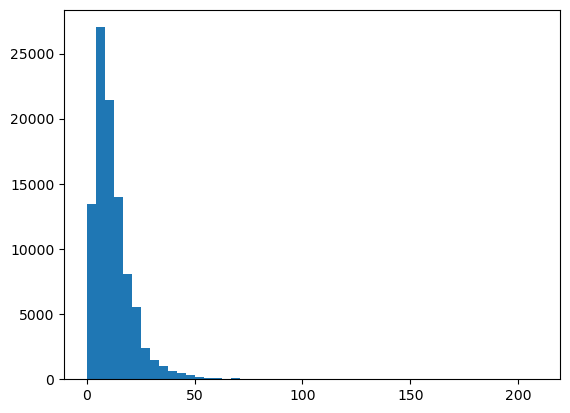

In [99]:
import matplotlib.pyplot as plt

plt.hist(orders["delivery_time_days"], bins=50)
plt.show()

In [101]:
orders["is_outlier"] = orders["delivery_time_days"] > 30

In [103]:
q1 = orders["delivery_time_days"].quantile(0.25)
q3 = orders["delivery_time_days"].quantile(0.75)
iqr = q3 - q1

orders["is_outlier"] = orders["delivery_time_days"] > (q3 + 1.5 * iqr)

In [105]:
mean = orders["delivery_time_days"].mean()
std = orders["delivery_time_days"].std()

orders["z_score"] = (orders["delivery_time_days"] - mean) / std
orders["is_outlier"] = orders["z_score"] > 3

In [107]:
orders["is_outlier"].mean()

0.016729549317965088

In [109]:
orders.groupby("is_outlier")["delay_vs_estimate"].mean()

is_outlier
False   -12.484810
True     23.853779
Name: delay_vs_estimate, dtype: float64

In [111]:
#Test if the outliers are real outliers or real data. 
#Real delivery time 12,5 days and 23 (True outlier) visualizes 23,9 days from late deliveries. Turns out to be real data.


In [113]:
dashboard = orders.groupby("is_outlier").agg({
    "delivery_time_days": ["mean", "median"],
    "delay_vs_estimate": ["mean", "median"],
    "order_id": "count"
})

dashboard

delivery_time_days        delay_vs_estimate        order_id
                         mean median              mean median    count
is_outlier                                                            
False               11.374755   10.0        -12.484810  -13.0    94862
True                54.372367   47.0         23.853779   20.0     1614

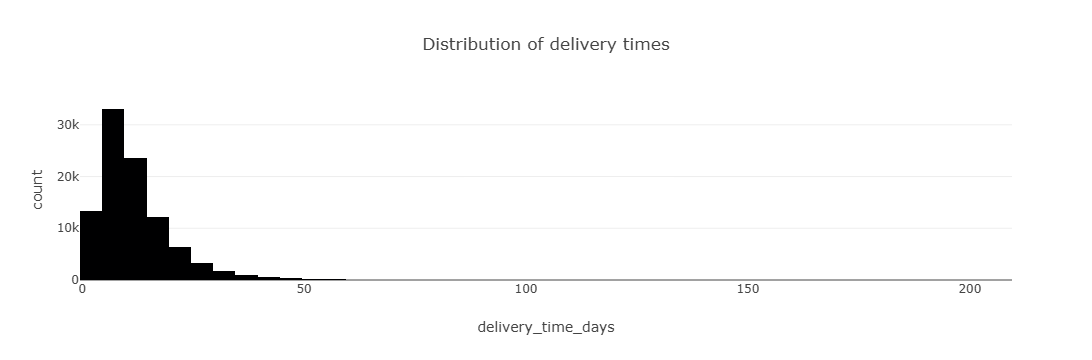

In [115]:
import plotly.express as px

fig = px.histogram(
    orders,
    x="delivery_time_days",
    nbins=50,
    title="Distribution of delivery times"
)

fig.show()

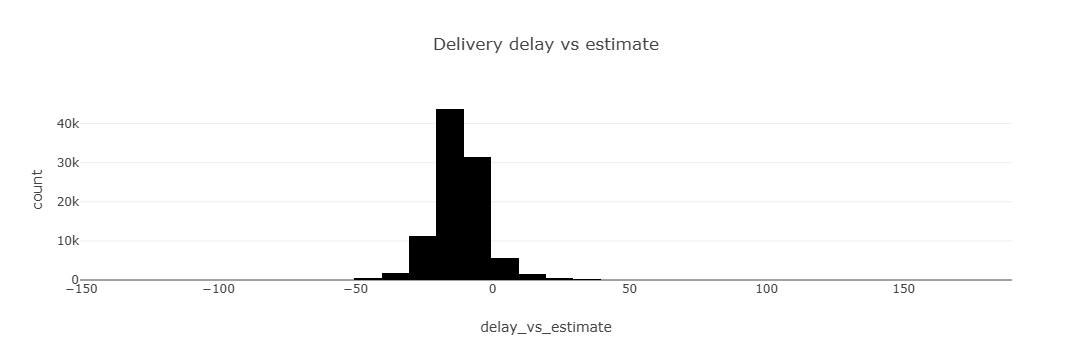

In [117]:
fig2 = px.histogram(
    orders,
    x="delay_vs_estimate",
    nbins=50,
    title="Delivery delay vs estimate"
)

fig2.show()

In [120]:
file_content = """
import streamlit as st
import pandas as pd

st.set_page_config(page_title="Olist Dashboard", layout="wide")

st.title("📦 Olist Dashboard")

orders = pd.read_csv(r"C:\\Users\\Lunda\\Documents\\DS assign\\Data2\\olist_orders_dataset.csv")

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

orders = orders.dropna(subset=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["delay_vs_estimate"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

st.sidebar.header("Filter")

max_days = st.sidebar.slider("Max delivery time", 0, 200, 30)
include_outliers = st.sidebar.checkbox("Include outliers", True)

orders["is_outlier"] = orders["delivery_time_days"] > 30

if not include_outliers:
    orders = orders[orders["is_outlier"] == False]

orders = orders[orders["delivery_time_days"] <= max_days]

st.metric("Avg delivery time", round(orders["delivery_time_days"].mean(), 2))
st.metric("Avg delay", round(orders["delay_vs_estimate"].mean(), 2))
st.metric("Orders", len(orders))

st.bar_chart(orders["delivery_time_days"].value_counts().sort_index())
"""

with open("dashboard.py", "w", encoding="utf-8") as f:
    f.write(file_content)

print("dashboard.py skapad!")

dashboard.py skapad!


In [122]:
#Dashboard Local URL: http://localhost:8501

from IPython.display import display, Markdown

display(Markdown("[Öppna dashboard](http://localhost:8501)"))

[Öppna dashboard](http://localhost:8501)

In [93]:
#Dataset from https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
